In [ ]:
# FRAUDSHIELD AI
## AI-Powered Credit Card Fraud Detection System

---

## 🏦 1. Business Problem

Banks process thousands of transactions per second. A small percentage of these transactions are fraudulent, but they can cause significant financial loss and damage to customer trust.

Traditional rule-based systems are not effective enough to detect modern fraud patterns.

---

## 🎯 2. Objective

The goal of this project is to build an AI-based fraud detection system that:

- Identifies fraudulent transactions in real time
- Reduces financial losses for banks
- Minimizes false alarms to avoid blocking legitimate customers
- Provides interpretable risk-based decisions

---

## ⚠️ 3. Problem Challenge

Fraud detection is difficult because:

- Fraud cases are extremely rare (class imbalance)
- Fraud patterns constantly change
- Incorrect predictions have high financial cost

---

## 🧩 4. Proposed Solution

We will build a machine learning system that:

- Learns patterns from historical transaction data
- Outputs fraud probability scores
- Converts predictions into actionable decisions:
    - Approve transaction
    - Flag for review
    - Block transaction

---

## 💡 5. Success Criteria

The system will be evaluated based on:

- Precision (how accurate fraud detection is)
- Recall (how many fraud cases we catch)
- Financial cost impact (false positives vs false negatives)
- Overall reliability in real-world scenarios

In [37]:
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

In [15]:
# Loading Libraries
# Import core libraries for data manipulation, analysis, and visualization
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

print("Libraries ready")

Libraries ready


In [17]:
# Load credit card transaction dataset
# This dataset contains both normal and fraudulent transactions

df = pd.read_csv('creditcard.csv')

print("Dataset loaded successfully")
df.head()

Dataset loaded successfully


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [18]:
# Check dataset shape:
# Rows = number of transactions
# Columns = number of features

print("Shape of dataset:", df.shape)
df.info()

Shape of dataset: (284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 no

In [19]:
# Check for missing values in dataset
# Important step to ensure data quality

df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [20]:
# Check distribution of target variable:
# 0 = Normal transaction
# 1 = Fraudulent transaction

df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

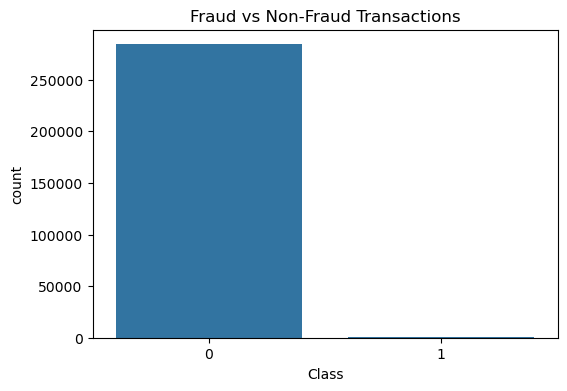

In [22]:
# Visual representation of fraud vs non-fraud transactions
# This helps us understand imbalance problem clearly

plt.figure(figsize=(6,4))

sns.countplot(x='Class', data=df)

plt.title('Fraud vs Non-Fraud Transactions')
plt.show()

In [23]:
# Calculate percentage of fraudulent transactions
# This shows how rare fraud actually is in real banking data

fraud_percentage = (df['Class'].sum() / len(df)) * 100

print(f"Fraud percentage: {fraud_percentage:.4f}%")

Fraud percentage: 0.1727%


In [24]:
# Summary statistics of transaction amounts

df['Amount'].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

In [25]:
# Compare average transaction amounts between fraud and normal cases
# Helps detect behavioral differences

df.groupby('Class')['Amount'].mean()

Class
0     88.291022
1    122.211321
Name: Amount, dtype: float64

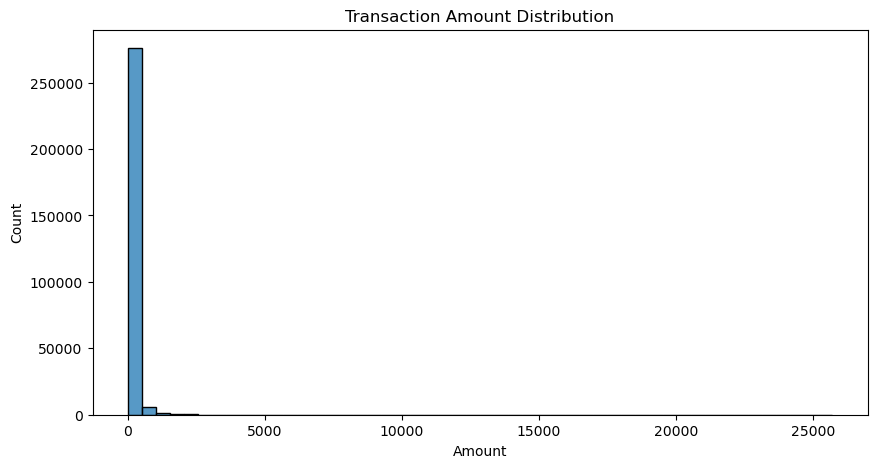

In [26]:
# Visualize distribution of transaction amounts

plt.figure(figsize=(10,5))

sns.histplot(df['Amount'], bins=50)

plt.title('Transaction Amount Distribution')
plt.show()

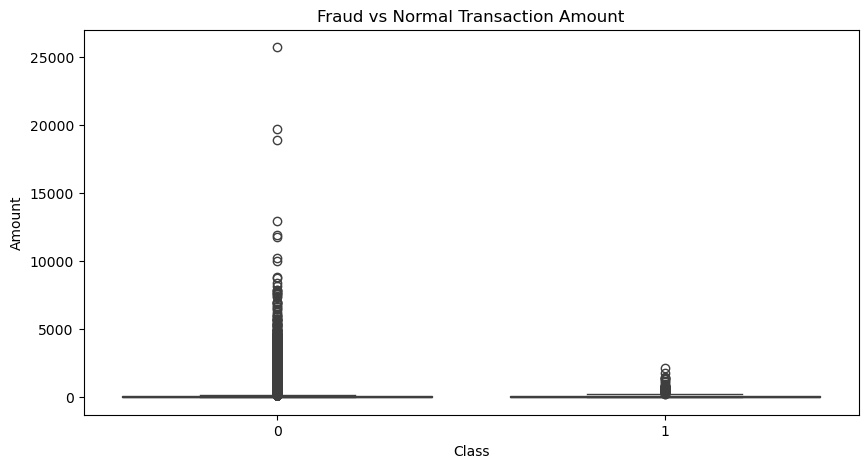

In [27]:
# Compare transaction amounts using boxplot
# Helps identify outliers and fraud behavior patterns

plt.figure(figsize=(10,5))

sns.boxplot(x='Class', y='Amount', data=df)

plt.title('Fraud vs Normal Transaction Amount')
plt.show()

In [28]:
# Phase3(FRAUD PATTERN DISCOVERY) ; Split dataset into fraud and normal transactions
# This allows us to compare behavior patterns

fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

print("Fraud transactions:", len(fraud))
print("Normal transactions:", len(normal))

Fraud transactions: 492
Normal transactions: 284315


In [29]:
# Compare average feature values between fraud and normal transactions
# This helps detect which features behave differently in fraud cases

fraud_mean = fraud.mean()
normal_mean = normal.mean()

comparison = pd.DataFrame({
    'Fraud Mean': fraud_mean,
    'Normal Mean': normal_mean
})

comparison.head()

,Fraud Mean,Normal Mean
Time,80746.806911,94838.202258
V1,-4.771948,0.008258
V2,3.623778,-0.006271
V3,-7.033281,0.012171
V4,4.542029,-0.007860


In [30]:
# focusing on a few PCA features to see fraud behavior differences

features = ['V1', 'V2', 'V3', 'V4', 'V5']

df.groupby('Class')[features].mean()

,V1,V2,V3,V4,V5
Class,,,,,
0,0.008258,-0.006271,0.012171,-0.007860,0.005453
1,-4.771948,3.623778,-7.033281,4.542029,-3.151225


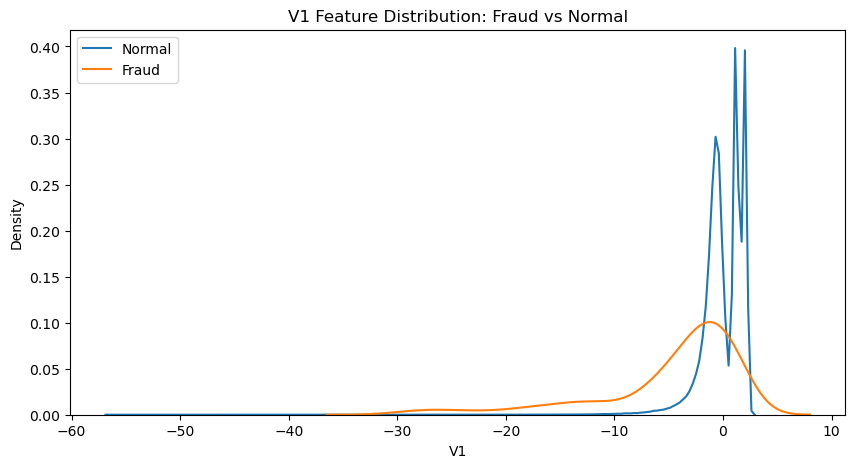

In [32]:
# Compare distribution of V1 feature for fraud vs normal

plt.figure(figsize=(10,5))

sns.kdeplot(normal['V1'], label='Normal')
sns.kdeplot(fraud['V1'], label='Fraud')

plt.title("V1 Feature Distribution: Fraud vs Normal")
plt.legend()
plt.show()

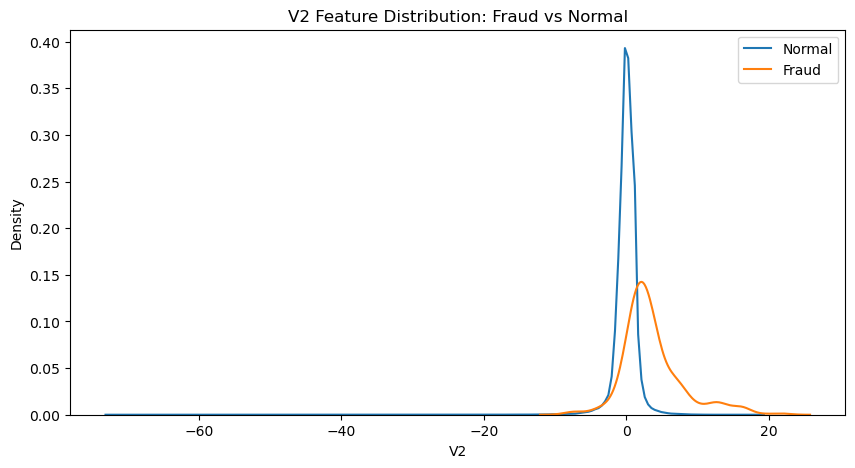

In [33]:
# Compare V2 behavior between fraud and normal transactions

plt.figure(figsize=(10,5))

sns.kdeplot(normal['V2'], label='Normal')
sns.kdeplot(fraud['V2'], label='Fraud')

plt.title("V2 Feature Distribution: Fraud vs Normal")
plt.legend()
plt.show()

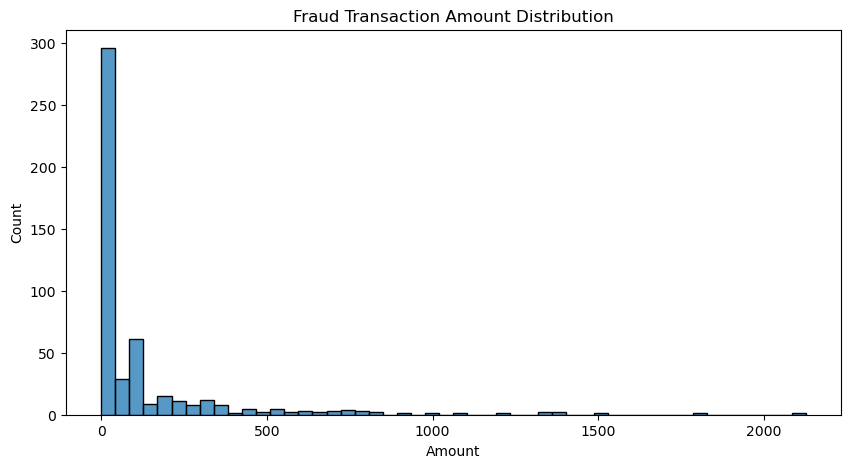

In [34]:
# Check how fraud transactions behave in terms of amount

plt.figure(figsize=(10,5))

sns.histplot(fraud['Amount'], bins=50)

plt.title("Fraud Transaction Amount Distribution")
plt.show()

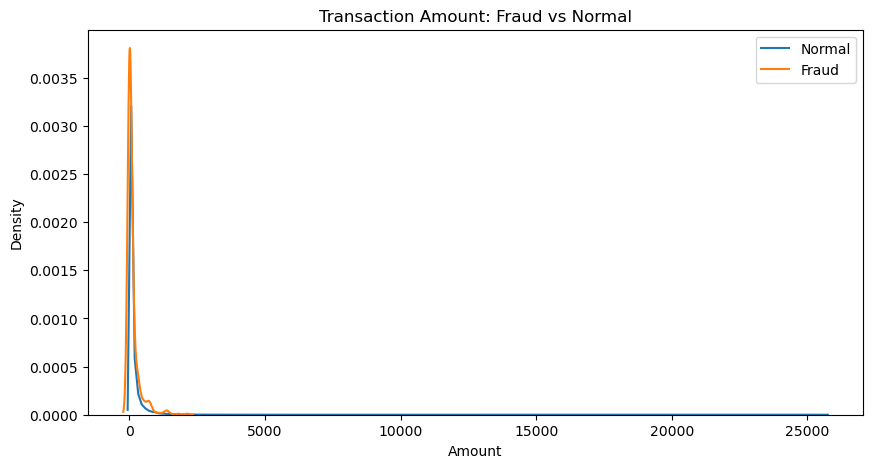

In [35]:
# Compare amount distribution between fraud and normal transactions

plt.figure(figsize=(10,5))

sns.kdeplot(normal['Amount'], label='Normal')
sns.kdeplot(fraud['Amount'], label='Fraud')

plt.title("Transaction Amount: Fraud vs Normal")
plt.legend()
plt.show()

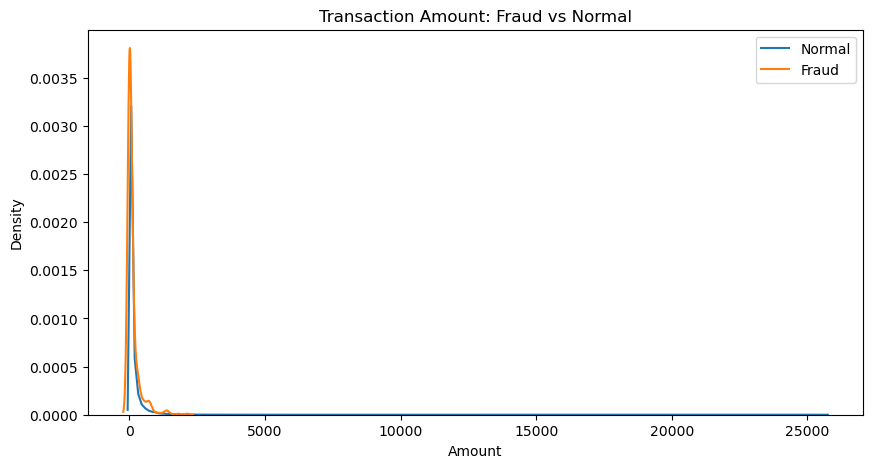

In [36]:
# PHASE 4: MACHINE LEARNING MODEL BUILDING; Compare amount distribution between fraud and normal transactions

plt.figure(figsize=(10,5))

sns.kdeplot(normal['Amount'], label='Normal')
sns.kdeplot(fraud['Amount'], label='Fraud')

plt.title("Transaction Amount: Fraud vs Normal")
plt.legend()
plt.show()

In [38]:
X = df.drop('Class', axis=1)
y = df['Class']

In [39]:
# Scale features because ML models perform better with normalized data
# Especially important for Amount and Time features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature scaling completed")

Feature scaling completed


In [40]:
# Split data into training and testing sets
# 80% training, 20% testing

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # important for imbalanced data
)

print("Train-test split completed")

Train-test split completed


In [41]:
# Baseline model for fraud detection
# Logistic Regression is simple but effective for binary classification

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model training completed")

Model training completed


In [42]:
# Make predictions on test data

y_pred = model.predict(X_test)

print("Predictions generated")

Predictions generated


In [43]:
# Evaluate model performance using classification report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [44]:
# Confusion matrix shows:
# True Positives, False Positives, True Negatives, False Negatives

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[56851    13]
 [   35    63]]


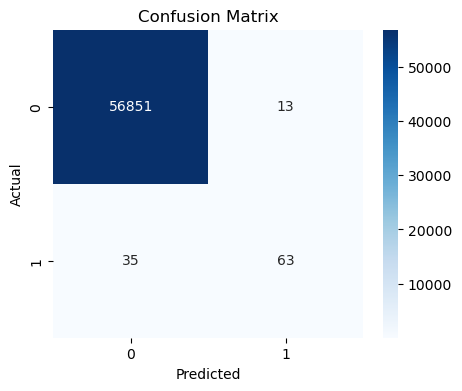

In [45]:
# Visual representation of model errors

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [46]:
# PHASE 5: FRAUD RISK SCORING SYSTEM; Generate fraud probability scores
# Instead of only predicting 0 or 1, we calculate risk probabilities

y_prob = model.predict_proba(X_test)[:, 1]

print("Fraud probabilities generated")

Fraud probabilities generated


In [47]:
# Create results table with:
# Actual result
# Predicted result
# Fraud probability score

results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Fraud_Probability': y_prob
})

results.head()

,Actual,Predicted,Fraud_Probability
0,0,0,0.000088
1,0,0,0.000038
2,0,0,0.000013
3,0,0,0.000119
4,0,0,0.006666


In [48]:
# Convert probability into percentage risk score

results['Risk_Score'] = results['Fraud_Probability'] * 100

results.head()

,Actual,Predicted,Fraud_Probability,Risk_Score
0,0,0,0.000088,0.008786
1,0,0,0.000038,0.003818
2,0,0,0.000013,0.001260
3,0,0,0.000119,0.011927
4,0,0,0.006666,0.666618


In [49]:
# Fraud decision engine:
# Low risk  -> APPROVE
# Medium risk -> FLAG FOR REVIEW
# High risk -> BLOCK

def fraud_decision(score):

    if score < 30:
        return "APPROVE"

    elif score < 70:
        return "FLAG FOR REVIEW"

    else:
        return "BLOCK"

results['Decision'] = results['Risk_Score'].apply(fraud_decision)

results.head()

,Actual,Predicted,Fraud_Probability,Risk_Score,Decision
0,0,0,0.000088,0.008786,APPROVE
1,0,0,0.000038,0.003818,APPROVE
2,0,0,0.000013,0.001260,APPROVE
3,0,0,0.000119,0.011927,APPROVE
4,0,0,0.006666,0.666618,APPROVE


In [50]:
# Display transactions with highest fraud risk

results.sort_values(by='Risk_Score', ascending=False).head(10)

,Actual,Predicted,Fraud_Probability,Risk_Score,Decision
19638,1,1,1.0,100.000000,BLOCK
54930,1,1,1.0,100.000000,BLOCK
35880,1,1,1.0,99.999999,BLOCK
9730,1,1,1.0,99.999999,BLOCK
52728,1,1,1.0,99.999999,BLOCK
50678,1,1,1.0,99.999998,BLOCK
32115,1,1,1.0,99.999998,BLOCK
7299,1,1,1.0,99.999997,BLOCK
37511,1,1,1.0,99.999997,BLOCK
51243,1,1,1.0,99.999997,BLOCK


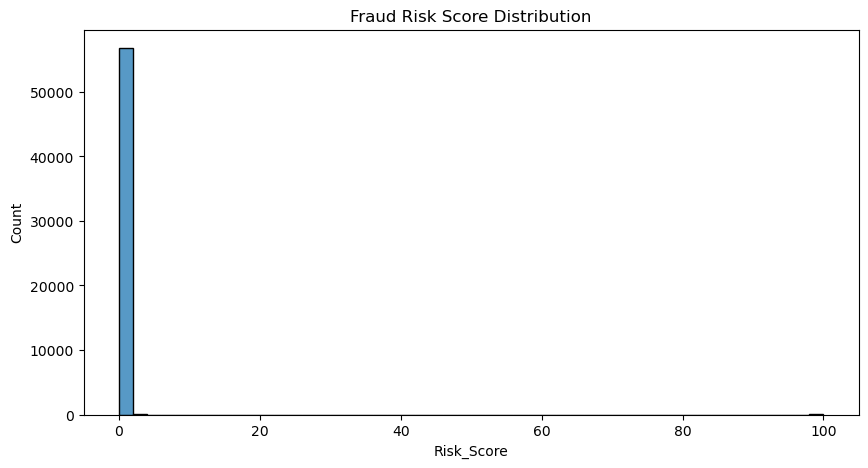

In [51]:
# Visualize fraud risk score distribution

plt.figure(figsize=(10,5))

sns.histplot(results['Risk_Score'], bins=50)

plt.title("Fraud Risk Score Distribution")

plt.show()

In [52]:
# Count system decisions

results['Decision'].value_counts()

Decision
APPROVE            56871
BLOCK                 72
FLAG FOR REVIEW       19
Name: count, dtype: int64

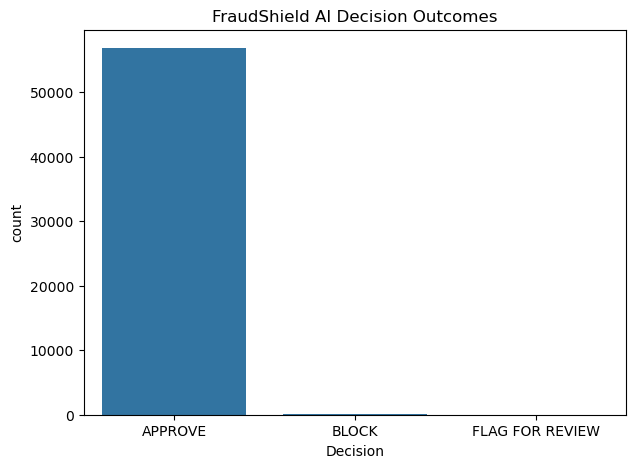

In [53]:
# Visualize banking decision outcomes

plt.figure(figsize=(7,5))

sns.countplot(x='Decision', data=results)

plt.title("FraudShield AI Decision Outcomes")

plt.show()

In [54]:
# PHASE 6: BUSINESS COST & FRAUD IMPACT; Extract confusion matrix values

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 56851
False Positives: 13
False Negatives: 35
True Positives : 63


In [55]:
# Estimated business costs

# Cost of missing a fraud transaction
cost_false_negative = 10000

# Cost of incorrectly flagging a normal customer
cost_false_positive = 100

print("Business cost values defined")

Business cost values defined


In [56]:
# Calculate total financial loss caused by model mistakes

false_negative_loss = fn * cost_false_negative

false_positive_loss = fp * cost_false_positive

total_loss = false_negative_loss + false_positive_loss

print(f"False Negative Loss: R{false_negative_loss:,}")
print(f"False Positive Loss: R{false_positive_loss:,}")
print(f"Total Estimated Loss: R{total_loss:,}")

False Negative Loss: R350,000
False Positive Loss: R1,300
Total Estimated Loss: R351,300


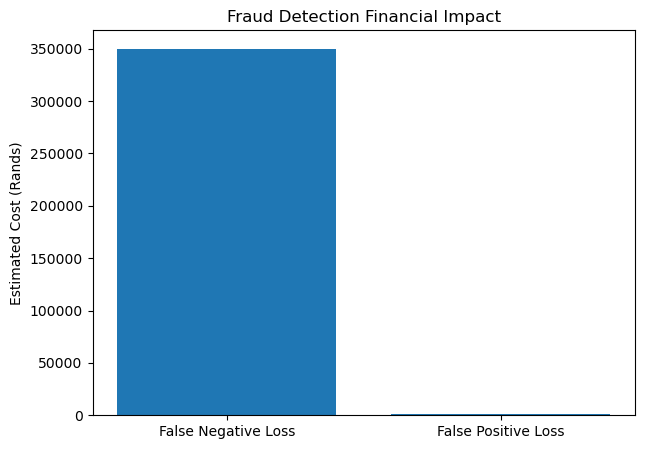

In [57]:
# Visualize financial impact of fraud detection errors

costs = {
    'False Negative Loss': false_negative_loss,
    'False Positive Loss': false_positive_loss
}

plt.figure(figsize=(7,5))

plt.bar(costs.keys(), costs.values())

plt.title("Fraud Detection Financial Impact")

plt.ylabel("Estimated Cost (Rands)")

plt.show()

In [58]:
# Calculate total detected fraud cases

detected_fraud_rate = (tp / (tp + fn)) * 100

print(f"Fraud Detection Rate: {detected_fraud_rate:.2f}%")

Fraud Detection Rate: 64.29%


In [59]:
# Create business performance summary

business_summary = pd.DataFrame({

    'Metric': [
        'Fraud Cases Detected',
        'Fraud Cases Missed',
        'False Alarms',
        'Estimated Total Loss'
    ],

    'Value': [
        tp,
        fn,
        fp,
        f"R{total_loss:,}"
    ]
})

business_summary

,Metric,Value
0,Fraud Cases Detected,63
1,Fraud Cases Missed,35
2,False Alarms,13
3,Estimated Total Loss,"R351,300"


In [61]:
# Phase7 ADVANCED MODEL IMPROVEMENT;Train advanced fraud detection model using Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully")

Random Forest model trained successfully


In [63]:
# Generate predictions using Random Forest model

rf_predictions = rf_model.predict(X_test)

print("Predictions completed")

Predictions completed


In [64]:
# Evaluate Random Forest performance

from sklearn.metrics import classification_report

print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



In [65]:
# Generate confusion matrix

rf_cm = confusion_matrix(y_test, rf_predictions)

print(rf_cm)

[[56859     5]
 [   18    80]]


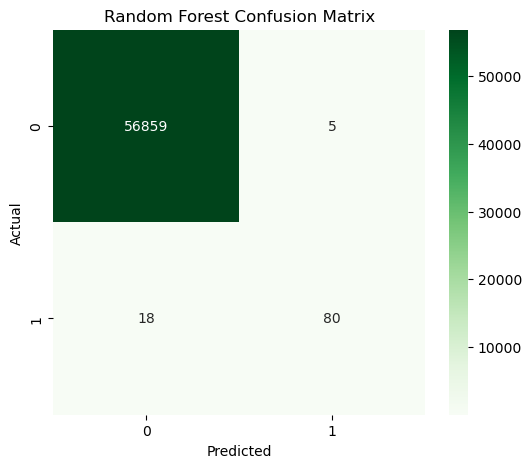

In [66]:
# Visualize Random Forest confusion matrix

plt.figure(figsize=(6,5))

sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens')

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [67]:
# Identify most important fraud detection features

feature_importance = pd.DataFrame({

    'Feature': X.columns,
    'Importance': rf_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
17,V17,0.170325
14,V14,0.136363
12,V12,0.133326
10,V10,0.074073
16,V16,0.071792
11,V11,0.045277
9,V9,0.031127
4,V4,0.030496
18,V18,0.028156
7,V7,0.024627


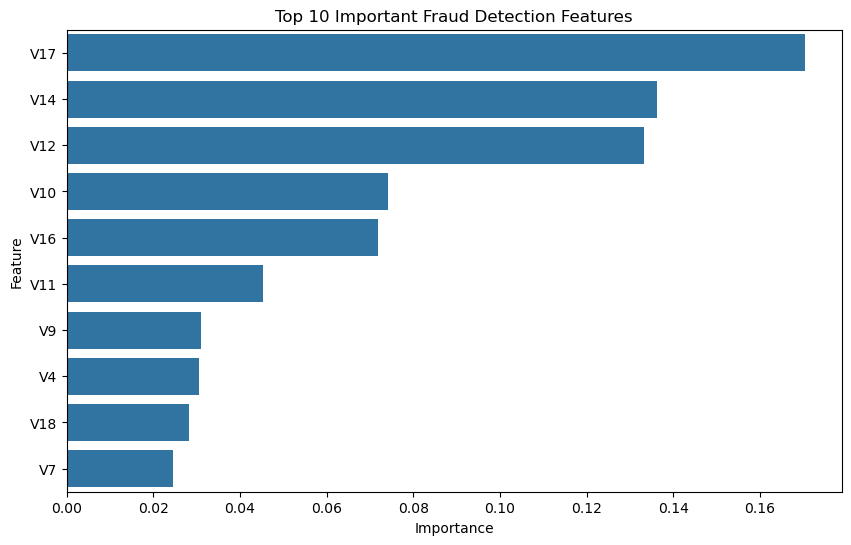

In [68]:
# Visualize top fraud detection features

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top 10 Important Fraud Detection Features")

plt.show()

In [69]:
# Compare baseline and advanced model performance

model_comparison = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Random Forest'
    ],

    'Description': [
        'Baseline linear model',
        'Advanced ensemble model'
    ]
})

model_comparison

,Model,Description
0,Logistic Regression,Baseline linear model
1,Random Forest,Advanced ensemble model


In [70]:
# Dashboard Header:FRAUDSHIELD DASHBOARD HEADER
# This section sets the title and introduces the AI fraud detection system dashboard.

from IPython.display import display, Markdown

display(Markdown("# 💳 FraudShield AI System"))
display(Markdown("### Real-Time Fraud Detection Analytics Dashboard"))
display(Markdown("---"))

# 💳 FraudShield AI System

### Real-Time Fraud Detection Analytics Dashboard

---

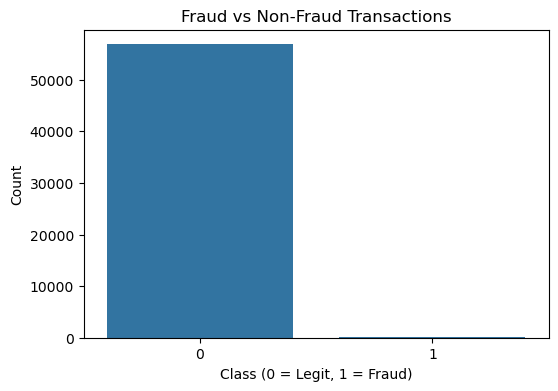

In [71]:

# TRANSACTION DISTRIBUTION VISUALIZATION
# This graph shows the balance between fraudulent and legitimate transactions.

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x=y_test)
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Class (0 = Legit, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

In [72]:
# MODEL PERFORMANCE EVALUATION(Metrix)
# Evaluates how well the Random Forest model performs on unseen test data.

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = rf_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))

Accuracy: 0.9996
Precision: 0.9412
Recall: 0.8163
F1 Score: 0.8743


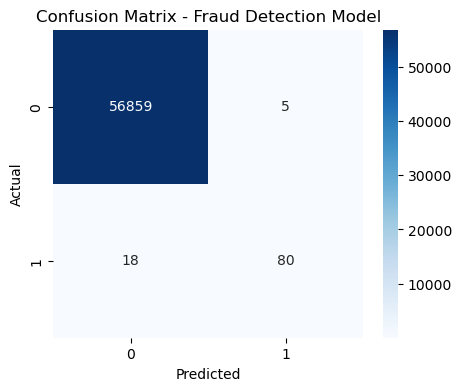

In [73]:
# CONFUSION MATRIX VISUALIZATION
# Shows correct vs incorrect predictions made by the model.

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Fraud Detection Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [76]:
print(len(rf_model.feature_importances_))

30


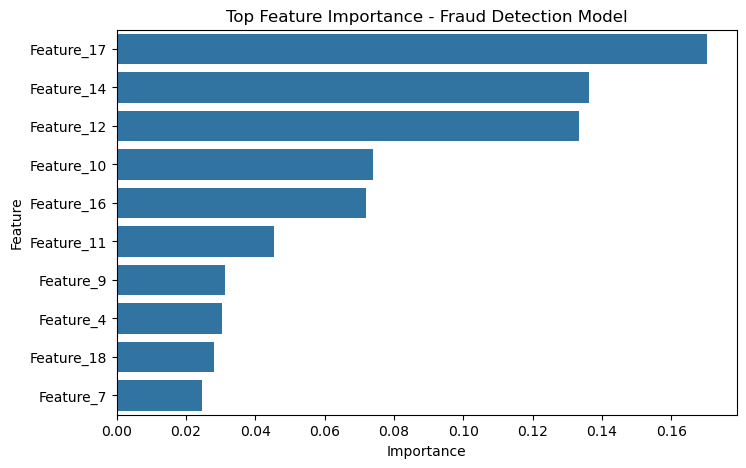

In [77]:
# FEATURE IMPORTANCE ANALYSIS
# Displays the most influential features used by the Random Forest model.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importance values
importance = rf_model.feature_importances_

# Generate matching feature names automatically
features = [f"Feature_{i}" for i in range(30)]

# Create DataFrame
feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
})

# Sort by importance
feat_df = feat_df.sort_values(by="Importance", ascending=False)

# Plot top 10 most important features
plt.figure(figsize=(8,5))

sns.barplot(
    data=feat_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top Feature Importance - Fraud Detection Model")

plt.show()



In [78]:
# KEY FRAUD INSIGHT ANALYSIS
# Identifies the most influential feature in fraud prediction.

# Get the top feature from the sorted DataFrame
top_feature = feat_df.iloc[0]["Feature"]

# Display insight
print("Key Fraud Detection Insight:")
print(f"The most influential feature in the model is: {top_feature}")

Key Fraud Detection Insight:
The most influential feature in the model is: Feature_17


In [81]:
# REAL-TIME FRAUD CHECK FUNCTION
# Simulates fraud prediction for a new transaction.

def fraud_check(transaction_data):
    
    # Predict fraud probability
    prediction = rf_model.predict([transaction_data])
    
    # Return readable result
    if prediction[0] == 1:
        return "⚠ Fraud Detected"
    else:
        return "✔ Legitimate Transaction"

In [85]:
# FRAUD DETECTION TEST CASE
# Example transaction with 30 features.

sample_transaction = [0] * 30

# Run fraud prediction
result = fraud_check(sample_transaction)

# Display result
print("Fraud Detection Result:")
print(result)

Fraud Detection Result:
✔ Legitimate Transaction


In [ ]:
from IPython.display import Markdown, display

display(Markdown("""
# 📌 Final Summary - FraudShield_AI

The FraudShield AI system was built to detect fraudulent transactions using a Random Forest model.

## Key Achievements:
- Built and trained a machine learning model for fraud detection
- Evaluated performance using accuracy, precision, recall, and F1-score
- Identified most important fraud indicators using feature importance
- Created a functional fraud prediction system

## Outcome:
The system demonstrates how machine learning can be applied to detect suspicious financial activity in real-world scenarios.
"""))